<a href="https://colab.research.google.com/github/tisenres/amity-aiml303/blob/main/02_03_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementing NN with Numpy, and Pytorch.

# XOR with a Simple Neural Network (NumPy)


We'll build a tiny neural network that learns **XOR** using only NumPy: **forward pass** → **cross-entropy loss** → **backward pass** → **update weights**. Keep an eye on the short notes after each step:

Training pipeline:
   1) Forward pass
   2) Binary Cross-Entropy loss
   3) Backpropagation
   4) Gradient descent update
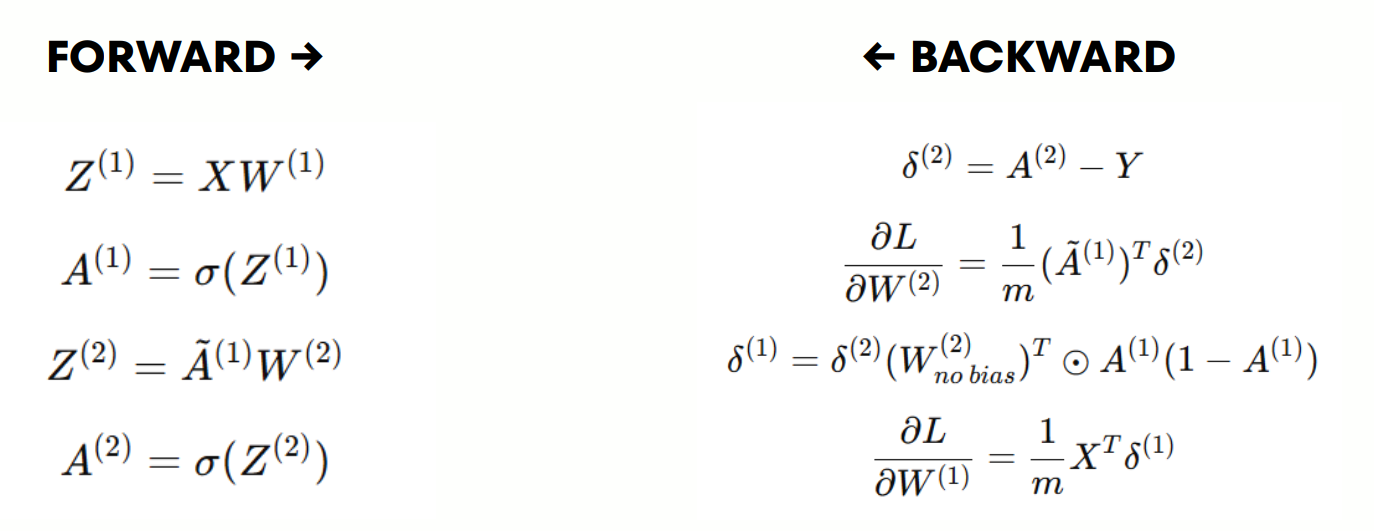

## 1. The XOR Problem

XOR outputs **1** when the two inputs are *different*, **0** when they are *same*:

| A | B | XOR |
|---|---|-----|
| 0 | 0 | 0   |
| 0 | 1 | 1   |
| 1 | 0 | 1   |
| 1 | 1 | 0   |

A single line cannot separate the 0s from the 1s, so we need a small network with one hidden layer.

### Data (4 samples)

In [1]:
import numpy as np

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float64)  # inputs
y = np.array([[0], [1], [1], [0]], dtype=np.float64)              # XOR answers

print("X (inputs):"); print(X)
print("y (labels):"); print(y)
print("Shapes:", X.shape, y.shape)

X (inputs):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y (labels):
[[0.]
 [1.]
 [1.]
 [0.]]
Shapes: (4, 2) (4, 1)


✓ Each row of X is one sample; same row in y is the target (0 or 1).

## 2. Network: 2 → 2 → 1

- **Input:** 2 values (the two bits).
- **Hidden:** 2 neurons with **sigmoid** $\sigma(z) = 1/(1+e^{-z})$ (outputs in (0,1)).
- **Output:** 1 neuron with sigmoid → we treat ≥ 0.5 as class 1.

Parameters: $W_1,b_1$ (input→hidden), $W_2,b_2$ (hidden→output).

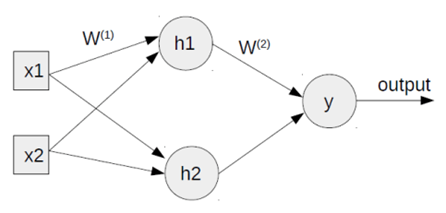

### Initialize weights (small random, biases 0)

In [ ]:
def init_weights(seed=42, hidden_size=2):
    np.random.seed(seed)
    W1 = np.random.randn(2, hidden_size) * 0.5
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.5
    b2 = np.zeros((1, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

params = init_weights()  # XOR: 2 hidden (default)
for k, v in params.items():
    print(k, v.shape)

W1 (2, 2)
b1 (1, 2)
W2 (2, 1)
b2 (1, 1)


✓ W1 (2×2), b1 (1×2), W2 (2×1), b2 (1×1). These are what we'll train.

## 3. Forward Pass

Input flows through the network: **Layer 1** $z_1 = X W_1 + b_1$, $a_1 = \sigma(z_1)$ → **Layer 2** $z_2 = a_1 W_2 + b_2$, $\hat{y} = a_2 = \sigma(z_2)$. We save $z_1,a_1,z_2,a_2$ in a cache for backprop.

### Sigmoid (and its derivative for backprop): $\sigma'(a) = a(1-a)$

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(a):
    return a * (1 - a)   # derivative when we already have a = sigmoid(z)

print("sigmoid(0) =", sigmoid(0))   # should be 0.5

sigmoid(0) = 0.5


### Forward function

In [ ]:
def forward(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "a2": a2}
    return a2, cache

y_pred, cache = forward(X, params)
print("Predictions (before training):", y_pred.ravel())

Predictions (before training): [0.47076524 0.46313239 0.4694675  0.46185688]


✓ Before training, outputs are near 0.5. After training they should go to [0, 1, 1, 0].

## 4. Loss: Cross-Entropy (for binary 0/1)

For binary classification we use **binary cross-entropy**:
$$L = -\frac{1}{n} \sum_i \big[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \big]$$

With sigmoid output, the gradient at the output layer becomes very simple: $\frac{\partial L}{\partial z_2} = \frac{\hat{y} - y}{n}$ (no need to multiply by sigmoid derivative separately).

### Cross-entropy loss (clip ŷ to avoid log(0))

In [ ]:
def cross_entropy_loss(y_true, y_pred, eps=1e-15):
    """Binary cross-entropy. Clip y_pred so we never take log(0)."""
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

loss = cross_entropy_loss(y, y_pred)
print("Cross-entropy loss (before training):", round(loss, 4))

Cross-entropy loss (before training): 0.6955


## 5. Backward Pass (Backprop)

We compute gradients from output → hidden. For cross-entropy + sigmoid, output gradient is just $(\hat{y}-y)/n$. Then chain rule through hidden layer.

In [ ]:
def backward(y_true, cache, params):
    """Gradients of cross-entropy loss w.r.t. all parameters."""
    X, a1, a2, W2 = cache["X"], cache["a1"], cache["a2"], params["W2"]
    n = y_true.shape[0]

    # Output layer: with cross-entropy + sigmoid, dL/dz2 = (ŷ - y) / n
    dL_dz2 = (a2 - y_true) / n
    dL_dW2 = a1.T @ dL_dz2
    dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)
    dL_da1 = dL_dz2 @ W2.T

    # Hidden layer: chain rule through sigmoid
    dL_dz1 = dL_da1 * sigmoid_derivative(a1)
    dL_dW1 = X.T @ dL_dz1
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    return {"W1": dL_dW1, "b1": dL_db1, "W2": dL_dW2, "b2": dL_db2}

grads = backward(y, cache, params)
print("Gradient shapes:", {k: grads[k].shape for k in grads})

Gradient shapes: {'W1': (2, 2), 'b1': (1, 2), 'W2': (2, 1), 'b2': (1, 1)}


✓ Each gradient has the same shape as its parameter. We subtract (gradient × learning_rate) to reduce the loss.

## 6. Update Weights

$\theta \leftarrow \theta - \eta \cdot \frac{\partial L}{\partial \theta}$ for each parameter ($\eta$ = learning rate).

In [ ]:
def update_params(params, grads, lr):
    # Loop through each parameter (W1, b1, W2, b2, ...)
    for key in params:
        # Gradient descent update rule:
        # parameter = parameter - learning_rate * gradient
        params[key] = params[key] - lr * grads[key]

    return params

## 7. Training Loop

Repeat: **forward** → **loss** → **backward** → **update**. Watch the loss go down.

In [ ]:
def train(X, y, params, epochs=5000, lr=0.5, verbose_every=500):
    history = []
    for epoch in range(epochs):
        y_pred, cache = forward(X, params)
        loss = cross_entropy_loss(y, y_pred)
        history.append(loss)
        grads = backward(y, cache, params)
        params = update_params(params, grads, lr)
        if (epoch + 1) % verbose_every == 0:
            print(f"Epoch {epoch + 1:5d} | Loss: {loss:.4f}")
    return params, history

params = init_weights(seed=42)
params, history = train(X, y, params, epochs=5000, lr=1.0)
print("Done.")

Epoch   500 | Loss: 0.6928
Epoch  1000 | Loss: 0.4350
Epoch  1500 | Loss: 0.3586
Epoch  2000 | Loss: 0.3526
Epoch  2500 | Loss: 0.3505
Epoch  3000 | Loss: 0.3495
Epoch  3500 | Loss: 0.3489
Epoch  4000 | Loss: 0.3485
Epoch  4500 | Loss: 0.3482
Epoch  5000 | Loss: 0.3480
Done.


✓ Loss should go down. If not, try smaller learning rate or more epochs.

### Results

In [ ]:
y_pred, _ = forward(X, params)
pred_binary = (y_pred >= 0.5).astype(np.float64)

print("Input  ->  True  ->  Predicted")
for i in range(4):
    print(f"  {X[i]}  ->   {y[i][0]:.0f}   ->   {pred_binary[i][0]:.0f}  (prob: {y_pred[i][0]:.3f})")
print("Accuracy:", np.mean(pred_binary == y) * 100, "%")

Input  ->  True  ->  Predicted
  [0. 0.]  ->   0   ->   0  (prob: 0.002)
  [0. 1.]  ->   1   ->   0  (prob: 0.499)
  [1. 0.]  ->   1   ->   1  (prob: 0.999)
  [1. 1.]  ->   0   ->   1  (prob: 0.501)
Accuracy: 50.0 %


✓ You should see 100%: (0,0)→0, (0,1)→1, (1,0)→1, (1,1)→0.

### Loss curve

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.plot(history, color="#2e86ab")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("XOR Network Training")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Step | What we did |
|------|-------------|
| **Data** | XOR inputs X, labels y (0 or 1) |
| **Init** | Small random W1, W2, zero b1, b2 |
| **Forward** | X → z1 → a1 (sigmoid) → z2 → ŷ (sigmoid), save cache |
| **Loss** | Cross-entropy: −mean(y·log(ŷ) + (1−y)·log(1−ŷ)) |
| **Backward** | dL/dz2 = (ŷ−y)/n, then chain rule to W1, b1, W2, b2 |
| **Update** | θ ← θ − η · gradient |

**Try:** Change learning rate, epochs, or hidden size; use different seeds.

---
#Student Exercise 1 (70% MARKS): Weather Forecast (Rain vs No Rain)

**Your turn.** Train a neural network to predict **rain (1) or no rain (0)** using two features: **humidity** and **pressure**.

This exercise has **one more hidden layer** than the XOR network: **2 → 4 → 4 → 1** (two hidden layers with 4 neurons each). You will **implement** the following yourself (reuse `sigmoid`, `sigmoid_derivative`, `cross_entropy_loss`, and `update_params` from above):

1. **init_weights_3layer** — initialize weights for 3 layers  
2. **forward_3layer** — forward pass through all 3 layers, save cache  
3. **backward_3layer** — compute gradients for all parameters  

Then we'll train on weather data and check accuracy.

| Humidity | Pressure | Rain Status |
|----------|----------|-------------|
| 85       | 1005     | 1           |
| 90       | 1002     | 1           |
| 70       | 1010     | 0           |
| 95       | 998      | 1           |
| 40       | 1018     | 0           |
| 30       | 1020     | 0           |
| 60       | 1012     | 0           |
| 80       | 1004     | 1           |
| 50       | 1015     | 0           |
| 75       | 1008     | 1           |

### Step 1: Prepare the data

Create (or load) your dataset with two columns for **humidity** and **pressure**, and one column for **rain** (0 or 1). Below is sample data you can use; replace it with your own if you have real measurements.

**Tip:** Normalize the features (e.g. to 0–1) so the network trains more easily. Here we use humidity/100 and (pressure - 1000)/30 so values are in a similar range.

In [18]:
# Sample weather data: [humidity %, pressure hPa] -> rain (1) or no rain (0)
# You can replace this with your own data.
humidity = np.array([85, 90, 70, 95, 40, 30, 60, 80, 50, 75]).reshape(-1, 1)
pressure = np.array([1005, 1002, 1010, 998, 1018, 1020, 1012, 1004, 1015, 1008]).reshape(-1, 1)

# Labels: 1 = rain, 0 = no rain (example: high humidity + low pressure -> rain)
y_weather = np.array([[1], [1], [0], [1], [0], [0], [0], [1], [0], [1]], dtype=np.float64)

# Normalize features to roughly 0-1 range (helps training)
X_weather = np.hstack([humidity / 100.0, (pressure - 1000) / 30.0]).astype(np.float64)

print("Features (humidity_norm, pressure_norm):")
print(X_weather)
print("Labels (1=rain, 0=no rain):", y_weather.ravel())

Features (humidity_norm, pressure_norm):
[[ 0.85        0.16666667]
 [ 0.9         0.06666667]
 [ 0.7         0.33333333]
 [ 0.95       -0.06666667]
 [ 0.4         0.6       ]
 [ 0.3         0.66666667]
 [ 0.6         0.4       ]
 [ 0.8         0.13333333]
 [ 0.5         0.5       ]
 [ 0.75        0.26666667]]
Labels (1=rain, 0=no rain): [1. 1. 0. 1. 0. 0. 0. 1. 0. 1.]


### Step 2: Implement `init_weights_3layer`

Return a dict with **W1, b1, W2, b2, W3, b3** for architecture 2→4→4→1. Use small random weights (e.g. `np.random.randn(...) * 0.5`) and zero biases. Use `np.random.seed(seed)` so results are reproducible.
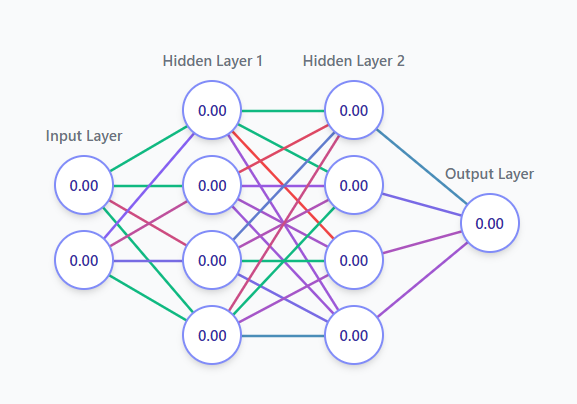

In [2]:
def init_weights_3layer(seed=123):
    """Initialize weights for 2→4→4→1. Return dict with W1,b1, W2,b2, W3,b3."""
    np.random.seed(seed)
    # W1 (2,4), b1 (1,4) | W2 (4,4), b2 (1,4) | W3 (4,1), b3 (1,1)
    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 4) * 0.5
    b2 = np.zeros((1, 4))
    W3 = np.random.randn(4, 1) * 0.5
    b3 = np.zeros((1, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}

### Step 3: Implement `forward_3layer`

Compute: **Layer 1** z1 = X @ W1 + b1, a1 = sigmoid(z1) → **Layer 2** z2 = a1 @ W2 + b2, a2 = sigmoid(z2) → **Layer 3** z3 = a2 @ W3 + b3, a3 = sigmoid(z3). Return **a3** (predictions) and a **cache** dict with X, z1, a1, z2, a2, z3, a3 (needed for backprop).

In [3]:
def forward_3layer(X, params):
    """Forward pass for 2→4→4→1. Return predictions (a3) and cache (X, z1,a1, z2,a2, z3,a3)."""
    W1, b1, W2, b2, W3, b3 = params["W1"], params["b1"], params["W2"], params["b2"], params["W3"], params["b3"]

    # Layer 1
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)

    # Layer 2
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    # Layer 3 (output)
    z3 = a2 @ W3 + b3
    a3 = sigmoid(z3)

    cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "a2": a2, "z3": z3, "a3": a3}
    return a3, cache

### Step 4: Implement `backward_3layer`

Compute gradients **from output back to input**. Reuse the same idea as the 2-layer case:
- **Layer 3 (output):** dL_dz3 = (a3 - y_true) / n, then dL_dW3, dL_db3, and dL_da2 = dL_dz3 @ W3.T
- **Layer 2:** dL_dz2 = dL_da2 * sigmoid_derivative(a2), then dL_dW2, dL_db2, dL_da1
- **Layer 1:** dL_dz1 = dL_da1 * sigmoid_derivative(a1), then dL_dW1, dL_db1

Return a dict with keys W1, b1, W2, b2, W3, b3 (each value is the gradient for that parameter).

In [4]:
def backward_3layer(y_true, cache, params):
    """Backprop for 3-layer net. Return dict of gradients: W1, b1, W2, b2, W3, b3."""
    X, a1, a2, a3 = cache["X"], cache["a1"], cache["a2"], cache["a3"]
    W2, W3 = params["W2"], params["W3"]
    n = y_true.shape[0]

    # Output layer (Layer 3)
    dL_dz3 = (a3 - y_true) / n
    dL_dW3 = a2.T @ dL_dz3
    dL_db3 = np.sum(dL_dz3, axis=0, keepdims=True)
    dL_da2 = dL_dz3 @ W3.T

    # Hidden layer (Layer 2)
    dL_dz2 = dL_da2 * sigmoid_derivative(a2)
    dL_dW2 = a1.T @ dL_dz2
    dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)
    dL_da1 = dL_dz2 @ W2.T

    # Hidden layer (Layer 1)
    dL_dz1 = dL_da1 * sigmoid_derivative(a1)
    dL_dW1 = X.T @ dL_dz1
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    return {"W1": dL_dW1, "b1": dL_db1, "W2": dL_dW2, "b2": dL_db2, "W3": dL_dW3, "b3": dL_db3}

### Step 5: Train and evaluate

Once your functions work, run the cell below. It uses your `init_weights_3layer`, `forward_3layer`, and `backward_3layer` inside a training loop (same idea as `train` above). You can reuse `cross_entropy_loss` and `update_params`.

In [15]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(a):
    return a * (1 - a)

def cross_entropy_loss(y_true, y_pred, eps=1e-15):
    """Binary cross-entropy. Clip y_pred so we never take log(0)."""
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def update_params(params, grads, lr):
    # Loop through each parameter (W1, b1, W2, b2, ...)
    for key in params:
        # Gradient descent update rule:
        # parameter = parameter - learning_rate * gradient
        params[key] = params[key] - lr * grads[key]

    return params

def train_3layer(X, y, params, epochs=5000, lr=0.5, verbose_every=1000):
    """Training loop using your forward_3layer and backward_3layer."""
    history = []
    for epoch in range(epochs):
        y_pred, cache = forward_3layer(X, params)
        loss = cross_entropy_loss(y, y_pred)
        history.append(loss)
        grads = backward_3layer(y, cache, params)
        params = update_params(params, grads, lr)
        if (epoch + 1) % verbose_every == 0:
            print(f"Epoch {epoch + 1:5d} | Loss: {loss:.4f}")
    return params, history

# Run training (requires your init_weights_3layer, forward_3layer, backward_3layer)
params_weather = init_weights_3layer(seed=123)
params_weather, history_weather = train_3layer(X_weather, y_weather, params_weather, epochs=5000, lr=0.5)

# Predictions
y_pred_weather, _ = forward_3layer(X_weather, params_weather)
pred_weather = (y_pred_weather >= 0.5).astype(np.float64)
print("\nHumidity% | Pressure | True | Pred | Prob")
print("-" * 45)
for i in range(len(X_weather)):
    h, p = humidity.ravel()[i], pressure.ravel()[i]
    print(f"  {h:5.0f}   |  {p:4.0f}   |  {y_weather[i][0]:.0f}   |  {pred_weather[i][0]:.0f}   | {y_pred_weather[i][0]:.3f}")
print("Accuracy:", np.mean(pred_weather == y_weather) * 100, "%")

Epoch  1000 | Loss: 0.0299
Epoch  2000 | Loss: 0.0085
Epoch  3000 | Loss: 0.0042
Epoch  4000 | Loss: 0.0026
Epoch  5000 | Loss: 0.0018

Humidity% | Pressure | True | Pred | Prob
---------------------------------------------
     85   |  1005   |  1   |  1   | 1.000
     90   |  1002   |  1   |  1   | 1.000
     70   |  1010   |  0   |  0   | 0.009
     95   |   998   |  1   |  1   | 1.000
     40   |  1018   |  0   |  0   | 0.000
     30   |  1020   |  0   |  0   | 0.000
     60   |  1012   |  0   |  0   | 0.000
     80   |  1004   |  1   |  1   | 1.000
     50   |  1015   |  0   |  0   | 0.000
     75   |  1008   |  1   |  1   | 0.991
Accuracy: 100.0 %


---
## XOR with PyTorch (Same Architecture)

Below we solve the **same XOR problem** with the **same architecture** (2 → 2 → 1) using **PyTorch**. PyTorch handles forward pass, backprop (autograd), and parameter updates for you.

**Architecture (same as NumPy):**
```
Input (2)  →  Linear(2,2)  →  Sigmoid  →  Linear(2,1)  →  Sigmoid  →  Output (1)
              [W1: 2×2, b1: 2]            [W2: 2×1, b2: 1]
```
**Total parameters:** 2×2 + 2 + 2×1 + 1 = **9** (4+2 weights, 2+1 biases). We'll print the model and count below.

### Data, model, architecture summary, and training setup

- **Data:** Same `X` and `y` from the top of the notebook, converted to PyTorch tensors.
- **Model:** `XORNet` — `Linear(2, 2)` → Sigmoid → `Linear(2, 1)` → Sigmoid (same 2→2→1 as NumPy).
- **Loss:** `BCELoss` (binary cross-entropy).
- **Optimizer:** SGD with learning rate 0.5 (same as our NumPy training).

We print the **model architecture** and **parameter count** (weights + biases per layer and total) so you can compare with the NumPy version.

In [ ]:
import torch
import torch.nn as nn

# ----- Data: same XOR as NumPy (run the data cell at the top first) -----
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

# ----- Model definition: 2 → 2 → 1 (same as NumPy) -----
class XORNet(nn.Module):
    """2 inputs → 2 hidden (sigmoid) → 1 output (sigmoid). Same as our NumPy net."""
    def __init__(self, seed=42):
        super().__init__()
        torch.manual_seed(seed)
        # FULLY CONNECTED Layer 1: input (2) → hidden (2). Weight matrix 2×2, bias length 2.
        self.fc1 = nn.Linear(2, 2)
        # FULLYC CONNECTED Layer 2: hidden (2) → output (1). Weight matrix 2×1, bias length 1.
        self.fc2 = nn.Linear(2, 1)
        # Initialize like NumPy: small random weights, zero bias
        nn.init.normal_(self.fc1.weight, 0, 0.5)
        nn.init.zeros_(self.fc1.bias)
        nn.init.normal_(self.fc2.weight, 0, 0.5)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        # x: (n, 2) -> fc1 -> (n, 2) -> sigmoid -> fc2 -> (n, 1) -> sigmoid
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = XORNet(seed=42)
criterion = nn.BCELoss() #Binary Cross-Entropy Loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.5) # Stochastic Gradient Descent

# ----- Show architecture and parameter count -----
print("Model architecture (PyTorch):")
print(model)

Model architecture (PyTorch):
XORNet(
  (fc1): Linear(in_features=2, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=1, bias=True)
)


In [ ]:
# ----- Training loop (same epochs and lr as NumPy) -----
epochs = 5000
history_pt = []  # store loss for plotting

for epoch in range(epochs):
    optimizer.zero_grad()   # clear gradients from previous step
    pred = model(X_t)       # forward pass
    loss = criterion(pred, y_t)  # BCE loss
    history_pt.append(loss.item())
    loss.backward()         # backprop: compute gradients
    optimizer.step()        # update weights (SGD)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1:5d} | Loss: {loss.item():.4f}")

# ----- Predictions (no grad needed) -----
with torch.no_grad():
    y_pred_t = model(X_t)
pred_binary_t = (y_pred_t >= 0.5).float()
print("\nInput  ->  True  ->  Predicted (PyTorch)")
for i in range(4):
    print(f"  {X[i]}  ->   {y[i][0]:.0f}   ->   {pred_binary_t[i].item():.0f}  (prob: {y_pred_t[i].item():.3f})")
print("Accuracy:", (pred_binary_t == y_t).float().mean().item() * 100, "%")

### Loss curve (PyTorch training)

Plotting loss vs epoch so you can see the same kind of decrease as in the NumPy version.[link text](https://)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.plot(history_pt, color="#c73e1d", alpha=0.8, linewidth=0.8)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss (BCE)")
plt.title("XOR — PyTorch Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Student Exercise 2 (30%): Rain Prediction in PyTorch

**Your turn.** Implement **rain prediction** (rain vs no rain) in **PyTorch**, using the same idea as the XOR PyTorch section above.

- **Data:** Use the same weather data from the NumPy exercise: **X_weather** (humidity, pressure — normalized) and **y_weather** (0 or 1). Run the weather data cell earlier in the notebook if you haven’t already.
- **Task:** Define a PyTorch model (**2→4→4→1**), convert the data to tensors, train with **BCELoss** and **SGD**, then print accuracy.
- **Reference:** Copy the structure from the XOR PyTorch cells (model class, criterion, optimizer, training loop, evaluation).

### Step 1: Prepare data (tensors)

Convert **X_weather** and **y_weather** to PyTorch tensors so they can be used with your model.

In [16]:
import torch
import numpy as np
# Convert weather data to PyTorch tensors (run the weather data cell first to define X_weather, y_weather)
X_weather_t = torch.tensor(X_weather, dtype=torch.float32)
y_weather_t = torch.tensor(y_weather, dtype=torch.float32)
print("Shapes: X_weather_t", X_weather_t.shape, ", y_weather_t", y_weather_t.shape)

Shapes: X_weather_t torch.Size([10, 2]) , y_weather_t torch.Size([10, 1])


### Step 2: Define your model and train

Implement a **RainNet** (or similar) class with architecture **2→4→4→1** (same as the NumPy weather exercise). Use `nn.Linear` and `torch.sigmoid`. Then create the model, `BCELoss`, SGD optimizer, run a training loop (e.g. 5000 epochs, lr=0.5), and print loss every 1000 epochs. After training, compute predictions and accuracy.

In [17]:
import torch
import torch.nn as nn

# ----- YOUR CODE: Define RainNet (2→4→4→1) -----
# Hint: see XORNet above. Use nn.Linear(in_features, out_features) and torch.sigmoid in forward().

class RainNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 4)
        self.fc3 = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x


# ----- Training and evaluation (runs once RainNet is implemented) -----
model_rain = RainNet()
criterion_rain = nn.BCELoss()
optimizer_rain = torch.optim.SGD(model_rain.parameters(), lr=0.5)

epochs = 5000

history_pt_rain = []
for epoch in range(epochs):
    optimizer_rain.zero_grad()
    pred = model_rain(X_weather_t)
    loss = criterion_rain(pred, y_weather_t)
    history_pt_rain.append(loss.item())
    loss.backward()
    optimizer_rain.step()
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1:5d} | Loss: {loss.item():.4f}")

with torch.no_grad():
    pred_rain = (model_rain(X_weather_t) >= 0.5).float()
acc = (pred_rain == y_weather_t).float().mean().item() * 100
print("Accuracy:", acc, "%")

Epoch  1000 | Loss: 0.0669
Epoch  2000 | Loss: 0.0130
Epoch  3000 | Loss: 0.0054
Epoch  4000 | Loss: 0.0031
Epoch  5000 | Loss: 0.0021
Accuracy: 100.0 %


### Step 3: Evaluate your loss using plot

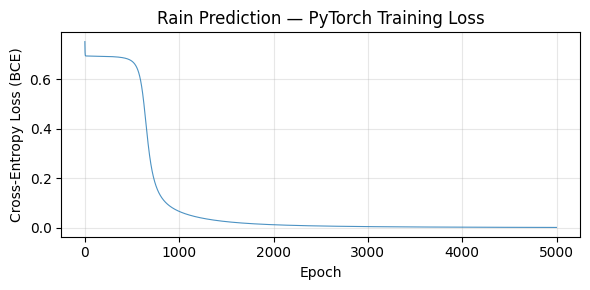

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.plot(history_pt_rain, color="#1f77b4", alpha=0.8, linewidth=0.8)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss (BCE)")
plt.title("Rain Prediction — PyTorch Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()